In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Load the breast cancer dataset
cancer = load_breast_cancer()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0
)

# Print the shapes as shown in the first block
print(X_train.shape)
print(X_test.shape)

# Initialize the Support Vector Classifier with C=100
svm = SVC(C=100)

# Fit the model to the training data
svm.fit(X_train, y_train)

# Calculate and print the test set accuracy
print("Test set accuracy: {:.2f}".format(svm.score(X_test, y_test)))

(426, 30)
(143, 30)
Test set accuracy: 0.94


In [2]:
from sklearn.preprocessing import MinMaxScaler

# Preprocessing using 0-1 scaling
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Learning an SVM on the scaled training data
svm.fit(X_train_scaled, y_train)

# Scoring on the scaled test set
print("Scaled test set accuracy: {:.2f}".format(
    svm.score(X_test_scaled, y_test)))

Scaled test set accuracy: 0.97


In [3]:
# preprocessing using zero mean and unit variance scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# learning an SVM on the scaled training data
svm.fit(X_train_scaled, y_train)

# scoring on the scaled test set
print("SVM test accuracy: {:.2f}".format(
    svm.score(X_test_scaled, y_test)))

SVM test accuracy: 0.96


In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the dataset
cancer = load_breast_cancer()

# Standardize the data (PCA is very sensitive to unscaled data)
scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

# Keep the first two principal components of the data
pca = PCA(n_components=2)

# Fit PCA model to breast cancer data
pca.fit(X_scaled)

# Transform data onto the first two principal components
X_pca = pca.transform(X_scaled)

# Print the comparison of shapes
print("Original shape: {}".format(str(X_scaled.shape)))
print("Reduced shape: {}".format(str(X_pca.shape)))

Original shape: (569, 30)
Reduced shape: (569, 2)


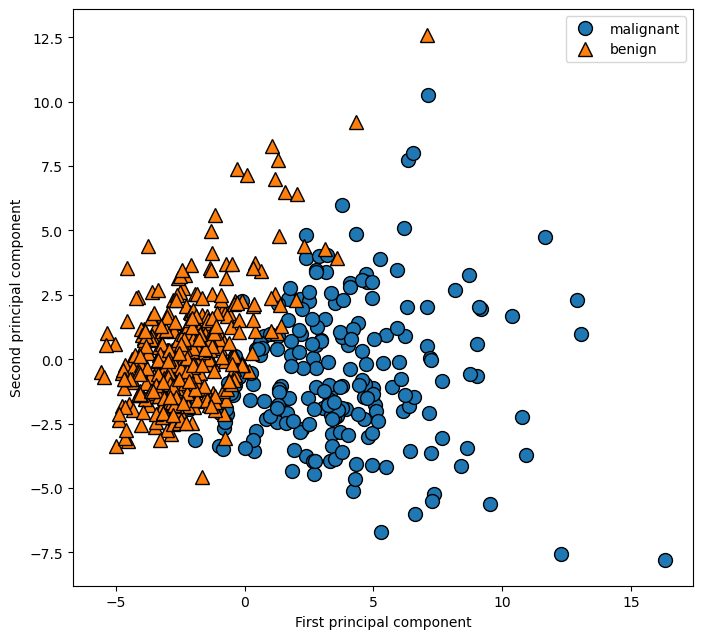

In [5]:
import matplotlib.pyplot as plt
import mglearn

# plot first vs. second principal component, colored by class
plt.figure(figsize=(8, 8))
mglearn.discrete_scatter(X_pca[:, 0], X_pca[:, 1], cancer.target)

plt.legend(cancer.target_names, loc="best")
plt.gca().set_aspect("equal")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.show()